In [1]:
import gcinfo
import pandas as pd
from io import StringIO

# NOTE(Ryan): Censored cells set to 5
#
# Data Source: IRCC COGNOS – Detentions Datamart
# Prepared by: Statistics and Performance Metrics Unit, Intelligence and Enforcement Branch
# Extracted: 2026-07-02
# Notes: Detention statistics for the 2024 calendar year, broken down by country of citizenship.
#
# Citizenship,"# of Detainees"
df_detainees_2024 = pd.read_csv(StringIO("""\
Citizenship,Detainees
Afghanistan,11
Albania,16
Algeria,127
Angola,7
Antigua and Barbuda,5
Argentina,5
Australia,5
Azerbaijan,5
"Bahama Islands, The",14
Bahrain,5
Bangladesh,44
Barbados,20
Belarus,5
Belgium,10
Belize,5
Bermuda,5
Bolivia,6
Bosnia-Hercegovina,5
Brazil,25
British Dependent Territories Citizen,5
Bulgaria,5
Burkina-Faso,5
Burundi,10
Cambodia,5
Canada,5
Cape Verde Islands,5
"Chad, Republic of",5
Chile,115
Colombia,98
"Congo, Democratic Republic of the",32
"Congo, People's Republic of the",5
Costa Rica,5
Croatia,5
Cuba,14
Cyprus,5
Czech Republic,5
Democratic Republic of Sudan,10
Denmark,5
Dominica,5
Dominican Republic,27
Ecuador,10
Egypt,10
El Salvador,20
Eritrea,8
Ethiopia,8
Federal Republic of Cameroon,25
Federal Republic of Germany,12
Fiji,5
France,37
Gabon Republic,5
Gambia,6
Georgia,15
Ghana,53
Greece,7
Guatemala,27
"Guinea, Republic of",23
Guyana,12
Haiti,38
Honduras,11
Hong Kong SAR,9
Hungary,20
India,794
Iran,27
Iraq,18
Israel,12
Italy,10
Jamaica,118
Japan,17
Jordan,21
Kazakhstan,5
Kenya,26
"Korea, Republic of",27
Laos,5
Latvia,5
Lebanon,7
Liberia,5
Libya,5
Lithuania,5
Macedonia,5
Malaysia,5
"Mali, Republic of",5
Malta,5
Mauritius,5
Mexico,680
Moldova,5
"Mongolia, People's Republic of",5
Morocco,34
Myanmar (Burma),5
Namibia,6
Nepal,7
New Zealand,5
Nicaragua,8
Nigeria,165
Norway,5
Pakistan,39
Palestinian Authority (Gaza/West Bank),5
"Panama, Republic of",5
People's Republic of Benin,5
People's Republic of China,105
Peru,17
Philippines,31
Poland,31
Portugal,24
Republic of Djibouti,5
Republic of Indonesia,5
Republic of Ireland,28
Republic of Ivory Coast,17
Republic of South Africa,5
Republic of the Niger,5
Romania,282
Russia,8
Rwanda,10
Senegal,22
"Serbia, Republic of",5
Sierra Leone,7
Singapore,5
Slovak Republic,5
Socialist Republic of Vietnam,80
"Somalia, Democratic Republic of",41
"South Sudan, Republic of",7
Spain,29
Sri Lanka,56
St. Kitts-Nevis,5
St. Lucia,9
St. Vincent and the Grenadines,21
Stateless,5
Sweden,13
Switzerland,5
Syria,6
Taiwan,10
Tajikistan,5
Thailand,6
The Netherlands,9
"Togo, Republic of",5
"Trinidad and Tobago, Republic of",11
Tunisia,18
Turkey,22
Uganda,6
UK - Brit. Nat. Overseas,5
UK - British citizen,87
Ukraine,6
United Kingdom and Colonies,5
United Republic of Tanzania,6
United States of America,147
Unknown,5
Uzbekistan,5
Vanuatu,5
Venezuela,5
"Yemen, Republic of",5
Zambia,5
Zimbabwe,10"""))
df_detainees_2024 = df_detainees_2024.sort_values(by="Detainees", ascending=False)
df_detainees_2024

,Citizenship,Detainees
61,India,794
83,Mexico,680
109,Romania,282
92,Nigeria,165
143,United States of America,147
...,...,...
144,Unknown,5
146,Vanuatu,5
147,Venezuela,5
148,"Yemen, Republic of",5


In [2]:
df_detainees_2024.head(10)

,Citizenship,Detainees
61,India,794
83,Mexico,680
109,Romania,282
92,Nigeria,165
143,United States of America,147
2,Algeria,127
66,Jamaica,118
27,Chile,115
98,People's Republic of China,105
28,Colombia,98


In [3]:
df_birth_2021, df_birth_2021_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/98100361-eng.zip")

Using cached file: cache\98100361-eng.zip


In [4]:
df_birth_2021_canada = df_birth_2021[df_birth_2021["GEO"] == "Canada"]
df_birth_2021_canada["GEO"].astype(str).unique()

array(['Canada'], dtype=object)

In [5]:
aggregates = ["Total – Place of birth",

              "Inside Canada",
              "Newfoundland and Labrador", "Prince Edward Island", "Nova Scotia", "New Brunswick", "Quebec", "Ontario", "Manitoba",
              "Saskatchewan", "Alberta", "British Columbia", "Yukon", "Northwest Territories", "Nunavut",

              "Outside Canada",
              "Americas",
              "North America", "Central America", "Caribbean and Bermuda", "South America",
              "Europe",
              "Western Europe", "Eastern Europe", "Northern Europe", "Southern Europe",
              "Africa",
              "Western Africa", "Eastern Africa", "Northern Africa", "Central Africa", "Southern Africa",
              "Asia",
              "West Central Asia and the Middle East", "Eastern Asia", "Southeast Asia", "Southern Asia",
              "Oceania",
              "Antarctica and Adjacent Islands",
              "Other",
]

In [6]:
# df_birth_2021_canada[~df_birth_2021_canada["Place of birth (290)"].isin(aggregates)]["Place of birth (290)", "Total - Non-permanent resident type[1]"].head()
df_birth_2021_canada_nations = df_birth_2021_canada[~df_birth_2021_canada["Place of birth (290)"].isin(aggregates)]
df_birth_2021_canada_nations

,REF_DATE,GEO,DGUID,Gender (3),Age (15C),Statistics (3),Place of birth (290),Coordinate,Non-permanent resident type (10):Total - Non-permanent resident type[1],Symbol,...,Non-permanent resident type (10):Non-permanent residents with work and study permits[6],Symbol.5,Non-permanent resident type (10):Other non-permanent resident types[7],Symbol.6,Non-permanent resident type (10):Not a non-permanent resident[8],Symbol.7,Non-permanent resident type (10):Non-immigrants[9],Symbol.8,Non-permanent resident type (10):Immigrants[10],Symbol.9
18,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Greenland,1.1.1.1.19,30,NaN,...,0,NaN,0,NaN,25,NaN,0,NaN,25,NaN
19,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Saint Pierre and Miquelon,1.1.1.1.20,510,NaN,...,15,NaN,0,NaN,465,NaN,105,NaN,355,NaN
20,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,United States of America,1.1.1.1.21,373380,NaN,...,1155,NaN,4565,NaN,346575,NaN,90485,NaN,256085,NaN
22,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Belize,1.1.1.1.23,2940,NaN,...,30,NaN,15,NaN,2750,NaN,735,NaN,2015,NaN
23,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Costa Rica,1.1.1.1.24,5890,NaN,...,55,NaN,35,NaN,5315,NaN,655,NaN,4655,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39143,2021,Canada,2021A000011124,Women+,75 years and over,"95% confidence interval upper bound, Count",Wallis and Futuna,1.3.15.3.284,0,...,...,0,...,0,...,0,...,0,...,0,...
39145,2021,Canada,2021A000011124,Women+,75 years and over,"95% confidence interval upper bound, Count",Antarctica,1.3.15.3.286,0,...,...,0,...,0,...,0,...,0,...,0,...
39146,2021,Canada,2021A000011124,Women+,75 years and over,"95% confidence interval upper bound, Count",Bouvet Island,1.3.15.3.287,0,...,...,0,...,0,...,0,...,0,...,0,...
39147,2021,Canada,2021A000011124,Women+,75 years and over,"95% confidence interval upper bound, Count",French Southern Territories,1.3.15.3.288,0,...,...,0,...,0,...,0,...,0,...,0,...


In [7]:
df_birth_2021_canada_nations_clean = df_birth_2021_canada_nations[
    (df_birth_2021_canada_nations["Gender (3)"] == "Total - Gender") &
    (df_birth_2021_canada_nations["Age (15C)"] == "Total - Age") &
    (df_birth_2021_canada_nations["Statistics (3)"] == "Count")
]
df_birth_2021_canada_nations_clean

,REF_DATE,GEO,DGUID,Gender (3),Age (15C),Statistics (3),Place of birth (290),Coordinate,Non-permanent resident type (10):Total - Non-permanent resident type[1],Symbol,...,Non-permanent resident type (10):Non-permanent residents with work and study permits[6],Symbol.5,Non-permanent resident type (10):Other non-permanent resident types[7],Symbol.6,Non-permanent resident type (10):Not a non-permanent resident[8],Symbol.7,Non-permanent resident type (10):Non-immigrants[9],Symbol.8,Non-permanent resident type (10):Immigrants[10],Symbol.9
18,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Greenland,1.1.1.1.19,30,NaN,...,0,NaN,0,NaN,25,NaN,0,NaN,25,NaN
19,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Saint Pierre and Miquelon,1.1.1.1.20,510,NaN,...,15,NaN,0,NaN,465,NaN,105,NaN,355,NaN
20,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,United States of America,1.1.1.1.21,373380,NaN,...,1155,NaN,4565,NaN,346575,NaN,90485,NaN,256085,NaN
22,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Belize,1.1.1.1.23,2940,NaN,...,30,NaN,15,NaN,2750,NaN,735,NaN,2015,NaN
23,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Costa Rica,1.1.1.1.24,5890,NaN,...,55,NaN,35,NaN,5315,NaN,655,NaN,4655,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Wallis and Futuna,1.1.1.1.284,15,NaN,...,0,NaN,0,NaN,15,NaN,0,NaN,15,NaN
285,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Antarctica,1.1.1.1.286,0,NaN,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
286,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,Bouvet Island,1.1.1.1.287,0,NaN,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
287,2021,Canada,2021A000011124,Total - Gender,Total - Age,Count,French Southern Territories,1.1.1.1.288,0,NaN,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN


In [8]:
df_birth_2021_canada_nations_clean = df_birth_2021_canada_nations_clean[[
    "Place of birth (290)",
    "Non-permanent resident type (10):Total - Non-permanent resident type[1]"
]].sort_values("Non-permanent resident type (10):Total - Non-permanent resident type[1]", ascending=False)
df_birth_2021_canada_nations_clean

,Place of birth (290),Non-permanent resident type (10):Total - Non-permanent resident type[1]
250,India,1166755
226,China,830985
241,Philippines,757415
115,United Kingdom,506035
20,United States of America,373380
...,...,...
280,Tuvalu,0
285,Antarctica,0
286,Bouvet Island,0
287,French Southern Territories,0


In [9]:
map_detainees_birth = {'Algeria': 'Algeria',
 'Bangladesh': 'Bangladesh',
 'Chile': 'Chile',
 'Colombia': 'Colombia',
 'Congo, Democratic Republic of the': 'Congo, Democratic Republic of the',
 'Dominican Republic': 'Dominican Republic',
 'France': 'France',
 'Ghana': 'Ghana',
 'Guatemala': 'Guatemala',
 'Haiti': 'Haiti',
 'India': 'India',
 'Iran': 'Iran',
 'Jamaica': 'Jamaica',
 'Kenya': 'Kenya',
 'Korea, Republic of': 'Korea, South',
 'Mexico': 'Mexico',
 'Morocco': 'Morocco',
 'Nigeria': 'Nigeria',
 'Pakistan': 'Pakistan',
 "People's Republic of China": 'China',
 'Philippines': 'Philippines',
 'Republic of Indonesia': 'Indonesia',
 'Romania': 'Romania',
 'Socialist Republic of Vietnam': 'Viet Nam',
 'Somalia, Democratic Republic of': 'Somalia',
 'Spain': 'Spain',
 'Sri Lanka': 'Sri Lanka',
 'UK - British citizen': 'United Kingdom',
 'United States of America': 'United States of America'
}

In [10]:
map_birth_detainees = {v: k for k, v in map_detainees_birth.items()}
map_birth_detainees

{'Algeria': 'Algeria',
 'Bangladesh': 'Bangladesh',
 'Chile': 'Chile',
 'Colombia': 'Colombia',
 'Congo, Democratic Republic of the': 'Congo, Democratic Republic of the',
 'Dominican Republic': 'Dominican Republic',
 'France': 'France',
 'Ghana': 'Ghana',
 'Guatemala': 'Guatemala',
 'Haiti': 'Haiti',
 'India': 'India',
 'Iran': 'Iran',
 'Jamaica': 'Jamaica',
 'Kenya': 'Kenya',
 'Korea, South': 'Korea, Republic of',
 'Mexico': 'Mexico',
 'Morocco': 'Morocco',
 'Nigeria': 'Nigeria',
 'Pakistan': 'Pakistan',
 'China': "People's Republic of China",
 'Philippines': 'Philippines',
 'Indonesia': 'Republic of Indonesia',
 'Romania': 'Romania',
 'Viet Nam': 'Socialist Republic of Vietnam',
 'Somalia': 'Somalia, Democratic Republic of',
 'Spain': 'Spain',
 'Sri Lanka': 'Sri Lanka',
 'United Kingdom': 'UK - British citizen',
 'United States of America': 'United States of America'}

In [11]:
_debug = df_detainees_2024[df_detainees_2024["Detainees"] > 25]
print(_debug.shape)
_debug

(30, 2)


,Citizenship,Detainees
61,India,794
83,Mexico,680
109,Romania,282
92,Nigeria,165
143,United States of America,147
2,Algeria,127
66,Jamaica,118
27,Chile,115
98,People's Republic of China,105
28,Colombia,98


In [12]:
# _debug["Citizenship"]= _debug["Citizenship"].map(map_detainees_birth)
# _debug

In [13]:
_debug.shape

(30, 2)

In [14]:
df_birth_2021_canada_nations_clean["Place of birth (290)"]#

250                                India
226                                China
241                          Philippines
115                       United Kingdom
20              United States of America
                     ...                
280                               Tuvalu
285                           Antarctica
286                        Bouvet Island
287          French Southern Territories
288    Heard Island and McDonald Islands
Name: Place of birth (290), Length: 250, dtype: object

In [15]:
df_birth_2021_canada_nations_clean["Place of birth (290)"] = df_birth_2021_canada_nations_clean["Place of birth (290)"].replace(map_birth_detainees)
print(df_birth_2021_canada_nations_clean.shape)
df_birth_2021_canada_nations_clean

(250, 2)


,Place of birth (290),Non-permanent resident type (10):Total - Non-permanent resident type[1]
250,India,1166755
226,People's Republic of China,830985
241,Philippines,757415
115,UK - British citizen,506035
20,United States of America,373380
...,...,...
280,Tuvalu,0
285,Antarctica,0
286,Bouvet Island,0
287,French Southern Territories,0


In [16]:
df_birth_2021_canada_nations_clean = df_birth_2021_canada_nations_clean[df_birth_2021_canada_nations_clean["Place of birth (290)"].isin(_debug["Citizenship"].unique().tolist())]
print(df_birth_2021_canada_nations_clean.shape)
df_birth_2021_canada_nations_clean

(29, 2)


,Place of birth (290),Non-permanent resident type (10):Total - Non-permanent resident type[1]
250,India,1166755
226,People's Republic of China,830985
241,Philippines,757415
115,UK - British citizen,506035
20,United States of America,373380
253,Pakistan,245520
206,Iran,213160
245,Socialist Republic of Vietnam,202335
80,France,177715
230,"Korea, Republic of",170880


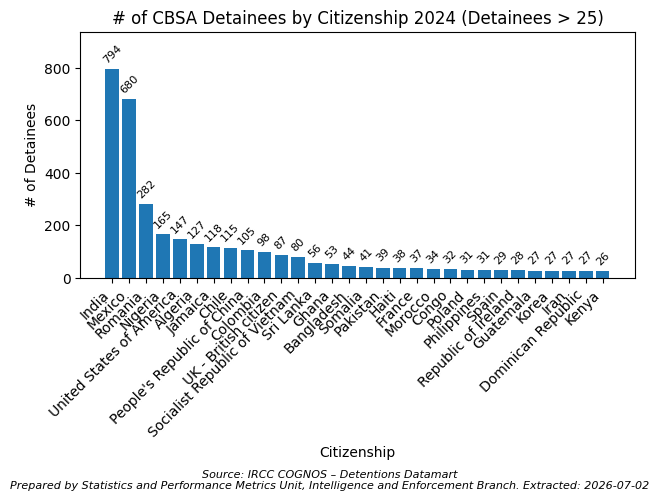

In [17]:
import matplotlib.pyplot as plt

X = 25
# Assume df_detainees_2024 already exists with columns "Citizenship" and "Detainees"
# Sort descending by Detainees for readability
df_plot = df_detainees_2024.sort_values("Detainees", ascending=False)
df_plot = df_plot[df_plot["Detainees"] > X]
df_plot["Citizenship"] = df_plot["Citizenship"].apply(lambda x: x.split(",")[0])

fig, ax = plt.subplots()
bars = ax.bar(df_plot["Citizenship"], df_plot["Detainees"])

# Add value labels on top of each bar (rotated 45°)
ax.bar_label(bars, padding=3, fontsize=8, rotation=45)

# Add a little extra headroom so labels aren't clipped
ax.margins(y=0.18)

ax.set_title(f"# of CBSA Detainees by Citizenship 2024 (Detainees > {X})")
ax.set_xlabel("Citizenship")
ax.set_ylabel("# of Detainees")

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)
plt.figtext(
    0.5, -0.03,
    "Source: IRCC COGNOS – Detentions Datamart\n"
    "Prepared by Statistics and Performance Metrics Unit, Intelligence and Enforcement Branch. Extracted: 2026-07-02",
    ha="center",
    fontsize=8,
    style="italic"
)
plt.tight_layout()
plt.show()

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Merge the two dataframes on nation name
df_pop = df_birth_2021_canada_nations_clean.rename(
    columns={
        "Place of birth (290)": "Nation",
        "Non-permanent resident type (10):Total - Non-permanent resident type[1]": "Population"
    }
)

df_det = _debug.rename(
    columns={
        "Citizenship": "Nation",
        "Detainees": "Detainees"
    }
)

df = pd.merge(df_pop, df_det, on="Nation", how="inner")

# Detainees per capita (per 1000 non-permanent residents for readability)
df["Detainees_per_1000"] = (df["Detainees"] / df["Population"]) * 1000

# Sort descending for a clearer bar chart
df = df.sort_values("Detainees_per_1000", ascending=False)
df

,Nation,Population,Detainees,Detainees_per_1000
13,Mexico,132220,680,5.142944
24,Chile,31565,115,3.643276
18,Romania,88645,282,3.181228
28,Spain,15025,29,1.930116
25,Ghana,29110,53,1.820680
27,Dominican Republic,15640,27,1.726343
15,Nigeria,111470,165,1.480219
19,Algeria,87835,127,1.445893
26,Guatemala,21150,27,1.276596
22,"Somalia, Democratic Republic of",34115,41,1.201817


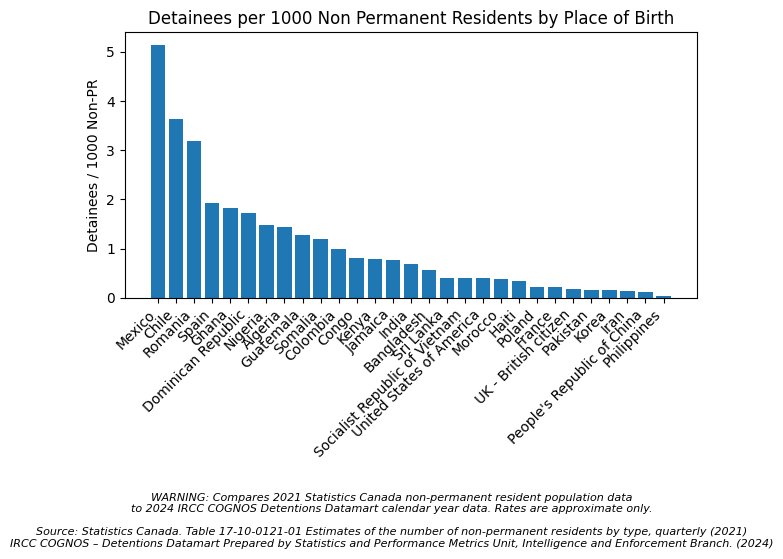

In [19]:
fig, ax = plt.subplots()

ax.bar(df["Nation"].apply(lambda x: x.split(",")[0]), df["Detainees_per_1000"])

ax.set_title("Detainees per 1000 Non Permanent Residents by Place of Birth")
# ax.set_xlabel("Place of Birth")
ax.set_ylabel("Detainees / 1000 Non-PR")

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.35)

plt.figtext(
    0.5, -0.15,
    "WARNING: Compares 2021 Statistics Canada non-permanent resident population data\n"
    "to 2024 IRCC COGNOS Detentions Datamart calendar year data. Rates are approximate only.\n\n"
    "Source: Statistics Canada. Table 17-10-0121-01 Estimates of the number of non-permanent residents by type, quarterly (2021)\n"
    "IRCC COGNOS – Detentions Datamart Prepared by Statistics and Performance Metrics Unit, Intelligence and Enforcement Branch. (2024)",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()

In [20]:
print(f"Nigeria	{(165 / 111470) * 1000}")
print(f"Ghana	{(53 / 29110) * 1000}")
print(f"Algeria	{(127 / 87835) * 1000}")
print(f"Congo, Democratic Republic of the {(32 / 39475) * 1000}")

Nigeria	1.4802188929756885
Ghana	1.8206801786327722
Algeria	1.445892867308021
Congo, Democratic Republic of the 0.8106396453451552


In [21]:
print(f"United States of America	{(147 / 373380) * 1000}")
print(f"France	{(37 / 177715) * 1000}")
print(f"UK - British citizen	{(87 / 506035) * 1000}")

United States of America	0.39370078740157477
France	0.20819852010241116
UK - British citizen	0.1719248668570356


In [22]:
print(f"Socialist Republic of Vietnam	{(80 / 202335) * 1000}")
print(f"People's Republic of China	{(105 / 830985) * 1000}")
print(f"Korea, Republic of	{(27 / 170880) * 1000}")
print(f"Philippines {(31 / 757415) * 1000}")

Socialist Republic of Vietnam	0.3953838930486569
People's Republic of China	0.12635607140923122
Korea, Republic of	0.15800561797752807
Philippines 0.04092868506697121
